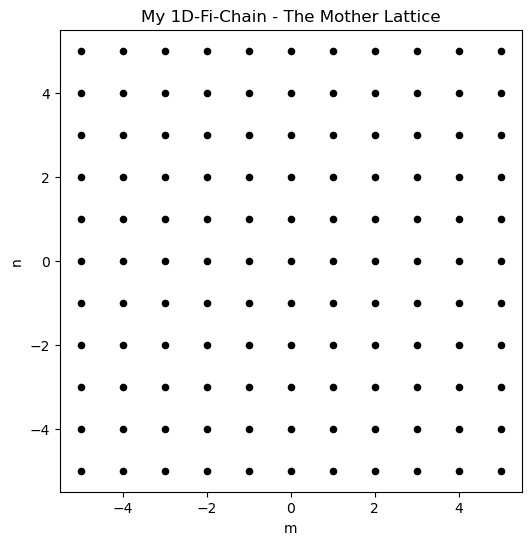

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Choose a finite range for m and n to plot
N = 5  # Plot points from -N to +N in both x and y

# 2. Generate the lattice points
points = []
for m in range(-N, N+1):
    for n in range(-N, N+1):
        points.append((m, n))

# 3. Plot the points
plt.figure(figsize=(6, 6))
xs, ys = zip(*points)
plt.scatter(xs, ys, s=20, color='black')

# 4. Add labels, remove grid lines, and fix aspect ratio
plt.title("My 1D-Fi-Chain - The Mother Lattice")
plt.xlabel('m')
plt.ylabel('n')
plt.gca().set_aspect('equal', adjustable='box')  # keeps squares square
plt.show()


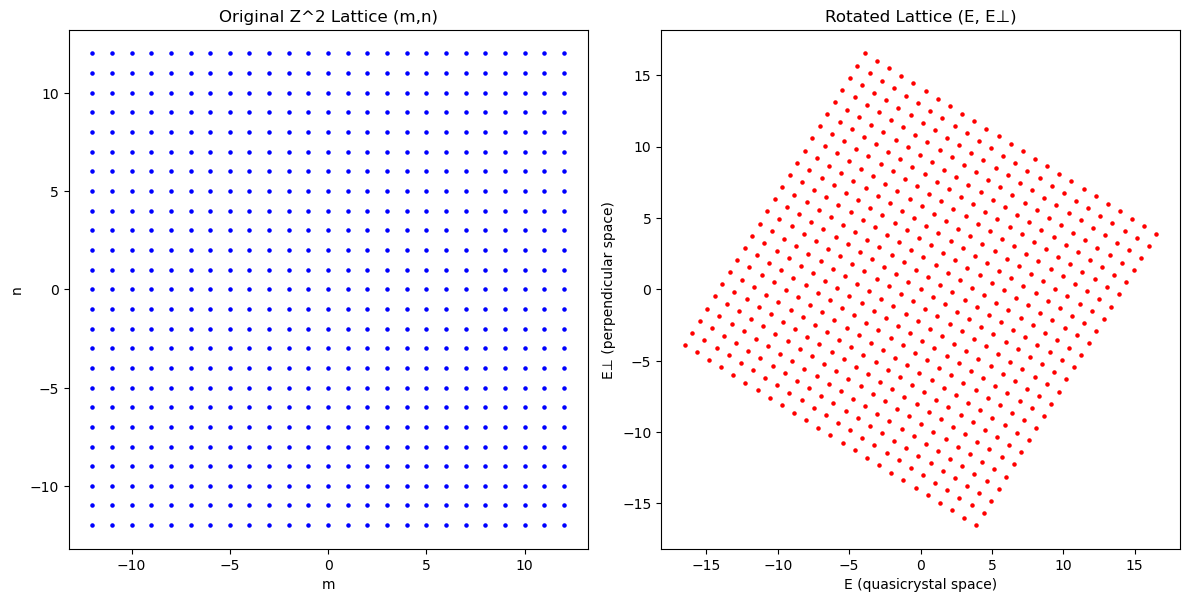

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Define the slope (for instance, 1/phi) ---
phi = (1 + np.sqrt(5))/2  # The golden ratio
slope = 1.0 / phi

# --- 2) Build the unit vectors for E (horizontal) and E^⊥ (vertical) ---
dir_vector = np.array([1.0, slope])
dir_length = np.linalg.norm(dir_vector)
e_hat = dir_vector / dir_length  # Unit vector along "quasicrystal space"

# Perpendicular direction: rotate by 90 degrees
perp_vector = np.array([-slope, 1.0])
perp_length = np.linalg.norm(perp_vector)
e_hat_perp = perp_vector / perp_length  # Unit vector along "perp space"

# --- 3) Form the 2x2 transformation matrix M ---
M = np.array([
    [ e_hat[0],      e_hat[1]      ],
    [ e_hat_perp[0], e_hat_perp[1] ]
])

# --- 4) Generate a larger patch of the Z^2 lattice and transform it ---
N = 12  # larger range
old_points = []
new_points = []
for m in range(-N, N+1):
    for n in range(-N, N+1):
        old_coords = np.array([m, n], dtype=float)
        new_coords = M @ old_coords  # matrix multiply
        old_points.append(old_coords)
        new_points.append(new_coords)

old_points = np.array(old_points)
new_points = np.array(new_points)

# --- 5) Plot the old lattice and the rotated lattice side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 5a) Left subplot: the original Z^2 lattice
axes[0].scatter(old_points[:,0], old_points[:,1], color='blue', s=5)
axes[0].set_title("Original Z^2 Lattice (m,n)")
axes[0].set_xlabel("m")
axes[0].set_ylabel("n")
axes[0].set_aspect('equal', adjustable='box')

# 5b) Right subplot: the rotated lattice in (E, E⊥) coordinates
axes[1].scatter(new_points[:,0], new_points[:,1], color='red', s=5)
axes[1].set_title("Rotated Lattice (E, E⊥)")
axes[1].set_xlabel("E (quasicrystal space)")
axes[1].set_ylabel("E⊥ (perpendicular space)")
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


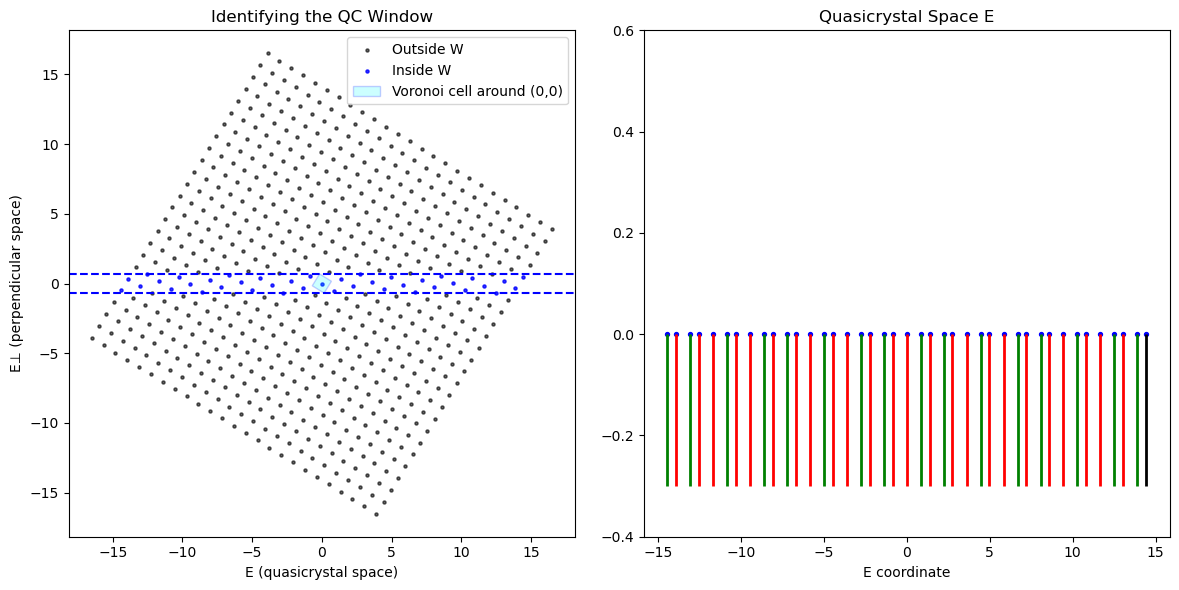

Approximate gap sizes: [0.526 0.851]
Ratio of larger to smaller gap ~ 1.6179


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# 1) Define rotation (E, E⊥)
# -----------------------------
phi = (1 + np.sqrt(5)) / 2  # Golden ratio
slope = 1.0 / phi

# Unit vectors for E (quasicrystal axis) and E⊥ (perpendicular axis)
dir_vector = np.array([1.0, slope])
e_hat = dir_vector / np.linalg.norm(dir_vector)

perp_vector = np.array([-slope, 1.0])
e_hat_perp = perp_vector / np.linalg.norm(perp_vector)

# 2×2 matrix taking (m,n) -> (E, E⊥)
M = np.array([
    [ e_hat[0],      e_hat[1]      ],
    [ e_hat_perp[0], e_hat_perp[1] ]
])

# ---------------------------------
# 2) Voronoi cell → acceptance window
# ---------------------------------
# The fundamental Voronoi cell around (0,0) in Z²:
#   -0.5 <= x <= 0.5,  -0.5 <= y <= 0.5
cell_corners = [
    (-0.5, -0.5),
    (-0.5,  0.5),
    ( 0.5,  0.5),
    ( 0.5, -0.5)
]

# Project corners onto E⊥ to find [w_min, w_max]
corner_projections = []
for (cx, cy) in cell_corners:
    corner_projections.append(cx*e_hat_perp[0] + cy*e_hat_perp[1])
w_min = min(corner_projections)
w_max = max(corner_projections)

# Rotate corners into (E,E⊥) for plotting the parallelogram
cell_corners_EEperp = [M @ np.array([cx, cy]) for (cx, cy) in cell_corners]

# ---------------------------------
# 3) Generate and classify lattice points
# ---------------------------------
N = 12
old_coords_list = []
new_coords_list = []

for m in range(-N, N+1):
    for n in range(-N, N+1):
        old_pt = np.array([m, n], dtype=float)
        new_pt = M @ old_pt  # (E, E⊥)
        old_coords_list.append(old_pt)
        new_coords_list.append(new_pt)

old_coords = np.array(old_coords_list)
new_coords = np.array(new_coords_list)

# Which points lie in the acceptance window [w_min, w_max]?
Eperp_vals = new_coords[:,1]
in_window = (Eperp_vals >= w_min) & (Eperp_vals <= w_max)

# Sort accepted points along E
accepted_E = new_coords[in_window, 0]
accepted_E_sorted = np.sort(accepted_E)
diffs = accepted_E_sorted[1:] - accepted_E_sorted[:-1]
mid_threshold = 0.5 * (diffs.min() + diffs.max())

# ---------------------------------
# 4) Make the plots
# ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,6))

### (A) Left Plot: Identifying the QC Window + Voronoi cell
axes[0].set_title("Identifying the QC Window")
axes[0].set_xlabel("E (quasicrystal space)")
axes[0].set_ylabel("E⊥ (perpendicular space)")

#  -- 1) Plot points: black = outside, blue = inside
axes[0].scatter(
    new_coords[~in_window,0], new_coords[~in_window,1],
    color='black', s=5, alpha=0.6, label="Outside W"
)
axes[0].scatter(
    new_coords[in_window,0], new_coords[in_window,1],
    color='blue', s=5, alpha=0.8, label="Inside W"
)

#  -- 2) Draw the acceptance window boundaries
axes[0].axhline(y=w_min, color='blue', linestyle='--')
axes[0].axhline(y=w_max, color='blue', linestyle='--')

#  -- 3) Draw/Fill the Voronoi cell (parallelogram) around origin
polygon = patches.Polygon(
    cell_corners_EEperp,
    closed=True, fill=True,
    facecolor='cyan', alpha=0.2,   # light shading
    edgecolor='blue', linewidth=1,
    label="Voronoi cell around (0,0)"
)
axes[0].add_patch(polygon)

axes[0].legend()
axes[0].set_aspect('equal', adjustable='box')

### (B) Right Plot: Quasicrystal Space (with color-coded gaps)
axes[1].set_title("Quasicrystal Space E")
axes[1].set_xlabel("E coordinate")
axes[1].set_ylim([-0.4, 0.6])  # just a little band

# Plot each accepted point as a vertical line (green for short gap, red for long)
for i in range(len(accepted_E_sorted) - 1):
    x_cur = accepted_E_sorted[i]
    gap = accepted_E_sorted[i+1] - x_cur
    color = 'green' if (gap <= mid_threshold) else 'red'
    axes[1].vlines(x_cur, 0, -0.3, color=color, linewidth=2)

# Last point has no "next" gap
axes[1].vlines(accepted_E_sorted[-1], 0, -0.3, color='black', linewidth=2)

# Also plot dots at y=0
axes[1].scatter(accepted_E_sorted, np.zeros_like(accepted_E_sorted),
                color='blue', s=8)

axes[1].set_aspect('auto')

plt.tight_layout()
plt.show()

# (Optional) Print approximate gap sizes
unique_gaps = np.unique(np.round(diffs, 3))
print("Approximate gap sizes:", unique_gaps)
print("Ratio of larger to smaller gap ~",
      round(unique_gaps.max() / unique_gaps.min(), 4))


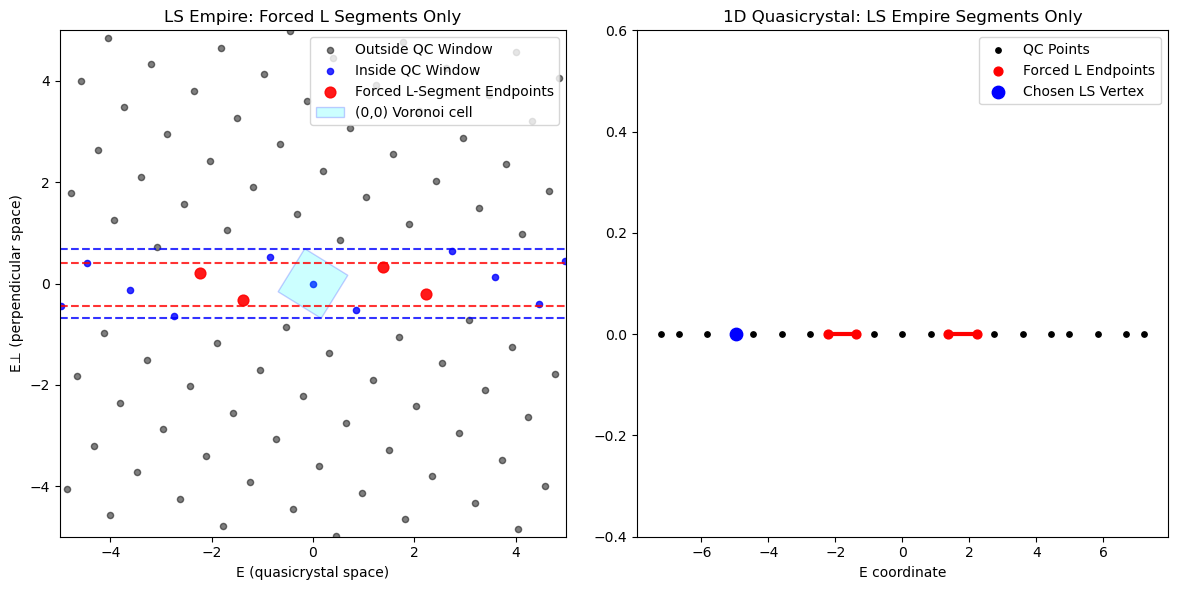

Chosen LS vertex at E ~ -4.98
Empire window in E⊥ = [ -0.449 , 0.402 ]
Number of forced L segments: 2


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# 1) Define rotation (E, E⊥)
# -----------------------------
phi = (1 + np.sqrt(5)) / 2  # Golden ratio
slope = 1.0 / phi

dir_vector = np.array([1.0, slope])
e_hat = dir_vector / np.linalg.norm(dir_vector)

perp_vector = np.array([-slope, 1.0])
e_hat_perp = perp_vector / np.linalg.norm(perp_vector)

# 2×2 matrix taking (m,n) -> (E, E⊥)
M = np.array([
    [ e_hat[0],      e_hat[1] ],
    [ e_hat_perp[0], e_hat_perp[1] ]
])

# -----------------------------
# 2) Voronoi cell => QC Window
# -----------------------------
cell_corners = [
    (-0.5, -0.5),
    (-0.5,  0.5),
    ( 0.5,  0.5),
    ( 0.5, -0.5)
]
corner_projections = [
    cx*e_hat_perp[0] + cy*e_hat_perp[1] 
    for (cx, cy) in cell_corners
]
w_min, w_max = min(corner_projections), max(corner_projections)

# For plotting the (0,0) Voronoi region
cell_corners_EEperp = [
    M @ np.array([cx, cy]) for (cx, cy) in cell_corners
]

# -----------------------------
# 3) Generate a patch of Z² & rotate
# -----------------------------
N = 6
all_coords_2d     = []
all_coords_EEperp = []

for m in range(-N, N+1):
    for n in range(-N, N+1):
        # Keep (m,n) as integers
        pt_2d = np.array([m, n], dtype=int)
        # Convert to float just for the matrix multiply
        pt_rot = M @ pt_2d.astype(float)  # (E, E⊥)
        all_coords_2d.append(pt_2d)
        all_coords_EEperp.append(pt_rot)

all_coords_2d     = np.array(all_coords_2d)      # shape (..., 2)
all_coords_EEperp = np.array(all_coords_EEperp)  # shape (..., 2)

E_vals     = all_coords_EEperp[:,0]
Eperp_vals = all_coords_EEperp[:,1]

# Who is inside the QC window?
in_window_mask = (Eperp_vals >= w_min) & (Eperp_vals <= w_max)

# -----------------------------
# 4) Build the 1D chain, track mother-lattice indices
# -----------------------------
indices_in_window = np.where(in_window_mask)[0]      
E_in_window       = E_vals[indices_in_window]

# Sort them by E
sort_order = np.argsort(E_in_window)
sorted_indices_in_window = indices_in_window[sort_order] 
E_1d = E_in_window[sort_order]

# Compute the gaps & label them short (S) or long (L)
diffs     = E_1d[1:] - E_1d[:-1]
threshold = 0.5 * (diffs.min() + diffs.max())
gap_types = np.where(diffs <= threshold, 'S', 'L')

# -----------------------------
# 5) Identify an L->S vertex (the "LS" boundary)
# -----------------------------
ls_index = None
for i in range(len(gap_types)-1):
    if gap_types[i] == 'L' and gap_types[i+1] == 'S':
        ls_index = i+1
        break
if ls_index is None:
    ls_index = len(E_1d)//2

ls_vertex_E = E_1d[ls_index]

# The boundary in mother-lattice indices is (ls_index, ls_index+1)
if ls_index+1 < len(E_1d):
    idx_left  = sorted_indices_in_window[ls_index]
    idx_right = sorted_indices_in_window[ls_index+1]
else:
    idx_left  = sorted_indices_in_window[ls_index-1]
    idx_right = sorted_indices_in_window[ls_index]

Eperp_left  = Eperp_vals[idx_left]
Eperp_right = Eperp_vals[idx_right]

# Empire window in perp-space
empire_w_min = min(Eperp_left, Eperp_right)
empire_w_max = max(Eperp_left, Eperp_right)

# -----------------------------
# 6) Determine which segments are forced L
# -----------------------------
forced_segments_mask = np.zeros(len(E_1d)-1, dtype=bool)

for i in range(len(gap_types)):
    if gap_types[i] == 'L':
        # Check for LL adjacency
        is_ll_left  = (i > 0) and (gap_types[i-1] == 'L')
        is_ll_right = (i < len(gap_types)-1) and (gap_types[i+1] == 'L')
        if is_ll_left or is_ll_right:
            continue
        # Otherwise, check empire range
        idxA = sorted_indices_in_window[i]
        idxB = sorted_indices_in_window[i+1]
        eperpA = Eperp_vals[idxA]
        eperpB = Eperp_vals[idxB]
        if (empire_w_min <= eperpA <= empire_w_max) and (empire_w_min <= eperpB <= empire_w_max):
            forced_segments_mask[i] = True

# Gather the forced endpoints (mother-lattice indices)
forced_endpoints_indices = []
for i, forced in enumerate(forced_segments_mask):
    if forced:
        idxA = sorted_indices_in_window[i]
        idxB = sorted_indices_in_window[i+1]
        forced_endpoints_indices.append(idxA)
        forced_endpoints_indices.append(idxB)

# Ensure int type for indexing
forced_endpoints_indices = np.unique(forced_endpoints_indices).astype(int)

forced_endpoints_mask_2D = np.zeros(len(all_coords_EEperp), dtype=bool)
forced_endpoints_mask_2D[forced_endpoints_indices] = True

forced_endpoints_mask_1D = np.zeros(len(E_1d), dtype=bool)
for i in range(len(E_1d)):
    mother_idx = sorted_indices_in_window[i]
    if forced_endpoints_mask_2D[mother_idx]:
        forced_endpoints_mask_1D[i] = True

# -----------------------------
# 7) Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------- (A) Left: (E,E⊥) ----------
ax_left = axes[0]
ax_left.set_title("LS Empire: Forced L Segments Only")
ax_left.set_xlabel("E (quasicrystal space)")
ax_left.set_ylabel("E⊥ (perpendicular space)")

# Increase marker sizes for clarity
outside_mask = ~in_window_mask
ax_left.scatter(
    E_vals[outside_mask], Eperp_vals[outside_mask],
    color='black', s=20, alpha=0.5, label="Outside QC Window"
)

inside_mask = in_window_mask & ~forced_endpoints_mask_2D
ax_left.scatter(
    E_vals[inside_mask], Eperp_vals[inside_mask],
    color='blue', s=20, alpha=0.8, label="Inside QC Window"
)

ax_left.scatter(
    E_vals[forced_endpoints_mask_2D], Eperp_vals[forced_endpoints_mask_2D],
    color='red', s=60, alpha=0.9, label="Forced L-Segment Endpoints"
)

# QC window boundaries
ax_left.axhline(y=w_min, color='blue', linestyle='--', alpha=0.8)
ax_left.axhline(y=w_max, color='blue', linestyle='--', alpha=0.8)

# empire boundaries
ax_left.axhline(y=empire_w_min, color='red', linestyle='--', alpha=0.8)
ax_left.axhline(y=empire_w_max, color='red', linestyle='--', alpha=0.8)

# Voronoi cell patch
poly = patches.Polygon(
    cell_corners_EEperp, closed=True, fill=True,
    facecolor='cyan', alpha=0.2,
    edgecolor='blue', linewidth=1, label="(0,0) Voronoi cell"
)
ax_left.add_patch(poly)

# Optionally set a zoom region for clarity
ax_left.set_xlim(-5, 5)
ax_left.set_ylim(-5, 5)

ax_left.legend()
ax_left.set_aspect('equal', 'box')

# ---------- (B) Right: 1D chain ----------
ax_right = axes[1]
ax_right.set_title("1D Quasicrystal: LS Empire Segments Only")
ax_right.set_xlabel("E coordinate")
ax_right.set_ylim([-0.4, 0.6])

# 1D points in black
ax_right.scatter(E_1d, np.zeros_like(E_1d),
                 color='black', s=15, label="QC Points")

# forced endpoints in red
ax_right.scatter(E_1d[forced_endpoints_mask_1D],
                 np.zeros_like(E_1d[forced_endpoints_mask_1D]),
                 color='red', s=40, zorder=5, label="Forced L Endpoints")

# forced L segments as red lines
for i, forced in enumerate(forced_segments_mask):
    if forced:
        x1 = E_1d[i]
        x2 = E_1d[i+1]
        ax_right.plot([x1, x2], [0, 0], color='red', linewidth=3)

# Mark the chosen LS vertex in blue
ax_right.scatter(ls_vertex_E, 0,
                 color='blue', s=80, zorder=6,
                 label="Chosen LS Vertex")

ax_right.legend()
ax_right.set_aspect('auto')

plt.tight_layout()
plt.show()

print("Chosen LS vertex at E ~", round(ls_vertex_E, 3))
print("Empire window in E⊥ = [", round(empire_w_min,3), ",", round(empire_w_max,3), "]")
print("Number of forced L segments:", np.sum(forced_segments_mask))


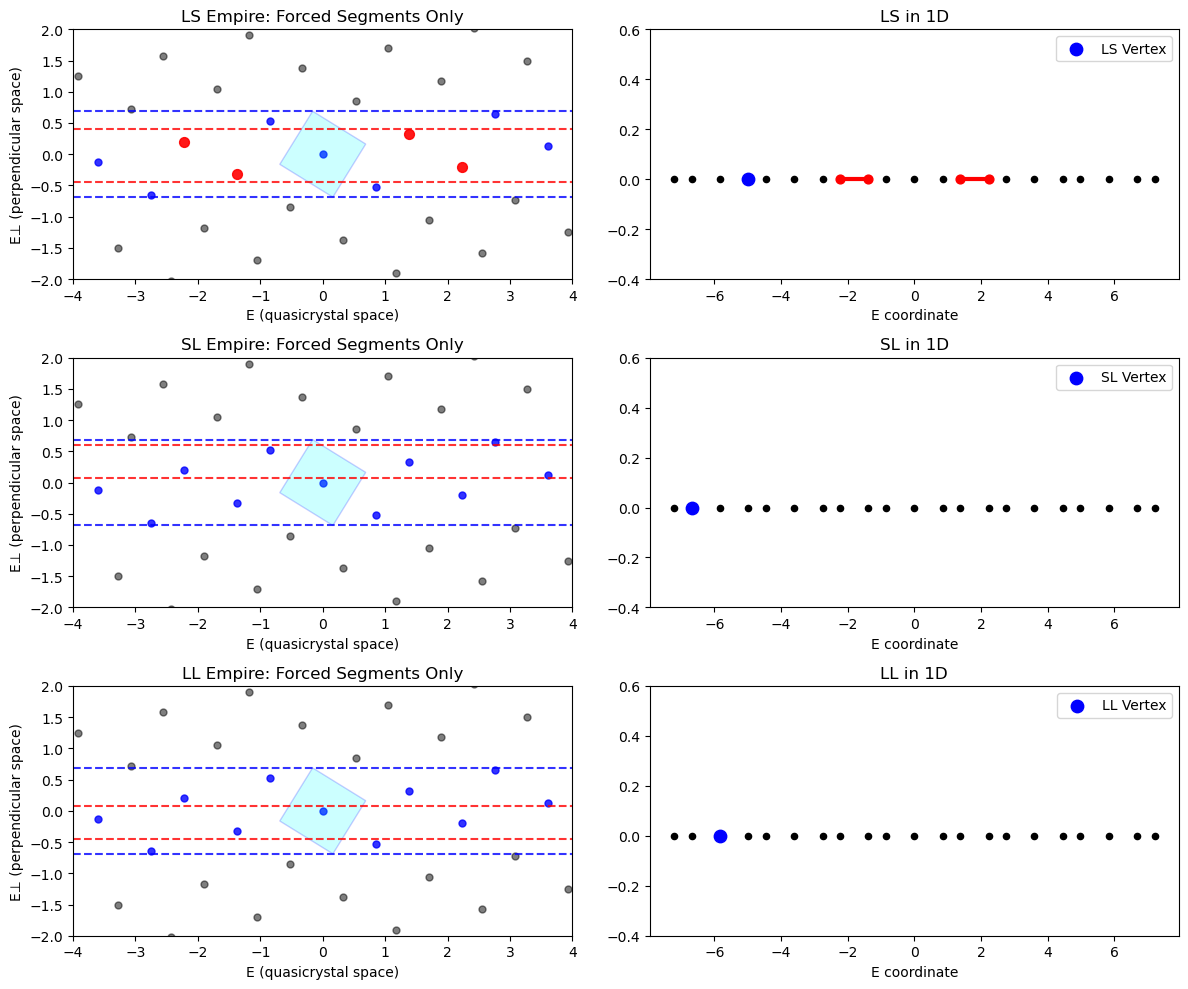

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -----------------------------
# 1) Define rotation (E, E⊥)
# -----------------------------
phi = (1 + np.sqrt(5)) / 2  # Golden ratio
slope = 1.0 / phi

dir_vector = np.array([1.0, slope])
e_hat = dir_vector / np.linalg.norm(dir_vector)

perp_vector = np.array([-slope, 1.0])
e_hat_perp = perp_vector / np.linalg.norm(perp_vector)

# 2×2 matrix taking (m,n) -> (E, E⊥)
M = np.array([
    [ e_hat[0],      e_hat[1] ],
    [ e_hat_perp[0], e_hat_perp[1] ]
])

# -----------------------------
# 2) Voronoi cell => QC Window
# -----------------------------
cell_corners = [
    (-0.5, -0.5),
    (-0.5,  0.5),
    ( 0.5,  0.5),
    ( 0.5, -0.5)
]
corner_projections = [
    cx*e_hat_perp[0] + cy*e_hat_perp[1] for (cx, cy) in cell_corners
]
w_min, w_max = min(corner_projections), max(corner_projections)

# For plotting the (0,0) Voronoi region
cell_corners_EEperp = [M @ np.array([cx, cy]) for (cx, cy) in cell_corners]

# -----------------------------
# 3) Generate a *smaller* patch of Z² (N=6) & rotate
# -----------------------------
N = 6  # <--- reduced from 12
all_coords_2d     = []
all_coords_EEperp = []

for m in range(-N, N+1):
    for n in range(-N, N+1):
        pt_2d = np.array([m, n], dtype=int)
        pt_rot = M @ pt_2d.astype(float)
        all_coords_2d.append(pt_2d)
        all_coords_EEperp.append(pt_rot)

all_coords_2d     = np.array(all_coords_2d)
all_coords_EEperp = np.array(all_coords_EEperp)

E_vals     = all_coords_EEperp[:, 0]
Eperp_vals = all_coords_EEperp[:, 1]

# Who is inside the QC window?
in_window_mask = (Eperp_vals >= w_min) & (Eperp_vals <= w_max)

# -----------------------------
# 4) Build the 1D chain, track mother-lattice indices
# -----------------------------
indices_in_window = np.where(in_window_mask)[0]
E_in_window       = E_vals[indices_in_window]

sort_order = np.argsort(E_in_window)
sorted_indices_in_window = indices_in_window[sort_order]
E_1d = E_in_window[sort_order]

# Compute the gaps & label them short (S) or long (L)
diffs     = E_1d[1:] - E_1d[:-1]
threshold = 0.5 * (diffs.min() + diffs.max())
gap_types = np.where(diffs <= threshold, 'S', 'L')

# ------------------------------------------------------
# 5)  A function that picks a boundary of type LS, SL, LL
#     then defines the empire window from its two endpoints.
# ------------------------------------------------------
def find_vertex_and_empire(vertex_type):
    desired_pair = tuple(vertex_type)
    found_index = None
    for i in range(len(gap_types)-1):
        pair = (gap_types[i], gap_types[i+1])
        if pair == desired_pair:
            found_index = i+1
            break
    if found_index is None:
        found_index = len(E_1d)//2
    
    vertex_E = E_1d[found_index]
    if found_index+1 < len(E_1d):
        idxA = sorted_indices_in_window[found_index]
        idxB = sorted_indices_in_window[found_index+1]
    else:
        idxA = sorted_indices_in_window[found_index-1]
        idxB = sorted_indices_in_window[found_index]

    eperpA = Eperp_vals[idxA]
    eperpB = Eperp_vals[idxB]
    empire_min = min(eperpA, eperpB)
    empire_max = max(eperpA, eperpB)
    return found_index, vertex_E, empire_min, empire_max

# ------------------------------------------------------
# 6) For each vertex type, define "forced segments" 
#    LS => single L (not LL), etc.
# ------------------------------------------------------
def get_forced_segments(vertex_type):
    v_index, v_E, empire_min, empire_max = find_vertex_and_empire(vertex_type)
    forced_segments_mask = np.zeros(len(E_1d)-1, dtype=bool)

    if vertex_type == "LS":
        for i in range(len(gap_types)):
            if gap_types[i] == 'L':
                # skip LL
                left_is_L  = (i>0)                and (gap_types[i-1]=='L')
                right_is_L = (i<len(gap_types)-1) and (gap_types[i+1]=='L')
                if left_is_L or right_is_L:
                    continue
                # single L => check endpoints
                idxA = sorted_indices_in_window[i]
                idxB = sorted_indices_in_window[i+1]
                eperpA = Eperp_vals[idxA]
                eperpB = Eperp_vals[idxB]
                if empire_min <= eperpA <= empire_max and empire_min <= eperpB <= empire_max:
                    forced_segments_mask[i] = True

    elif vertex_type == "SL":
        for i in range(len(gap_types)):
            if gap_types[i] == 'S':
                # skip SS
                left_is_S  = (i>0)                and (gap_types[i-1]=='S')
                right_is_S = (i<len(gap_types)-1) and (gap_types[i+1]=='S')
                if left_is_S or right_is_S:
                    continue
                idxA = sorted_indices_in_window[i]
                idxB = sorted_indices_in_window[i+1]
                eperpA = Eperp_vals[idxA]
                eperpB = Eperp_vals[idxB]
                if empire_min <= eperpA <= empire_max and empire_min <= eperpB <= empire_max:
                    forced_segments_mask[i] = True

    elif vertex_type == "LL":
        for i in range(len(gap_types)-1):
            if gap_types[i]=='L' and gap_types[i+1]=='L':
                idxA = sorted_indices_in_window[i]
                idxM = sorted_indices_in_window[i+1]
                idxB = sorted_indices_in_window[i+2]
                eperpA = Eperp_vals[idxA]
                eperpM = Eperp_vals[idxM]
                eperpB = Eperp_vals[idxB]
                if (empire_min<=eperpA<=empire_max and 
                    empire_min<=eperpM<=empire_max and
                    empire_min<=eperpB<=empire_max):
                    forced_segments_mask[i]   = True
                    forced_segments_mask[i+1] = True

    forced_endpoints = []
    for i, forced in enumerate(forced_segments_mask):
        if forced:
            idxA = sorted_indices_in_window[i]
            idxB = sorted_indices_in_window[i+1]
            forced_endpoints.append(idxA)
            forced_endpoints.append(idxB)

    forced_endpoints = np.unique(forced_endpoints).astype(int)
    forced_endpoints_mask_2D = np.zeros(len(all_coords_EEperp), dtype=bool)
    forced_endpoints_mask_2D[forced_endpoints] = True

    return (v_index, v_E,
            forced_segments_mask, forced_endpoints_mask_2D,
            empire_min, empire_max)

# ------------------------------------------------------
# 7) Plot function for a single vertex type
# ------------------------------------------------------
def plot_vertex_type(vertex_type, axleft, axright):
    (v_index, v_E,
     forced_segments_mask, forced_endpoints_mask_2D,
     empire_w_min, empire_w_max) = get_forced_segments(vertex_type)

    # (A) Left: (E,E⊥)
    axleft.set_title(f"{vertex_type} Empire: Forced Segments Only")
    axleft.set_xlabel("E (quasicrystal space)")
    axleft.set_ylabel("E⊥ (perpendicular space)")

    # Optional: Zoom in
    axleft.set_xlim([-4, 4])   # <--- Zoom the E range
    axleft.set_ylim([-2, 2])   # <--- Zoom the E⊥ range

    outside_mask = ~in_window_mask
    axleft.scatter(
        E_vals[outside_mask], Eperp_vals[outside_mask],
        color='black', s=25, alpha=0.5  # bigger points
    )

    inside_mask = in_window_mask & ~forced_endpoints_mask_2D
    axleft.scatter(
        E_vals[inside_mask], Eperp_vals[inside_mask],
        color='blue', s=25, alpha=0.8
    )

    # forced endpoints => red
    axleft.scatter(
        E_vals[forced_endpoints_mask_2D], Eperp_vals[forced_endpoints_mask_2D],
        color='red', s=50, alpha=0.9  # bigger red points
    )

    # QC boundaries (blue dashed)
    axleft.axhline(y=w_min, color='blue', linestyle='--', alpha=0.8)
    axleft.axhline(y=w_max, color='blue', linestyle='--', alpha=0.8)

    # empire boundaries (red dashed)
    axleft.axhline(y=empire_w_min, color='red', linestyle='--', alpha=0.8)
    axleft.axhline(y=empire_w_max, color='red', linestyle='--', alpha=0.8)

    # Voronoi cell
    poly = patches.Polygon(
        cell_corners_EEperp, closed=True, fill=True,
        facecolor='cyan', alpha=0.2,
        edgecolor='blue', linewidth=1
    )
    axleft.add_patch(poly)
    axleft.set_aspect('equal', 'box')

    # (B) Right: 1D chain
    axright.set_title(f"{vertex_type} in 1D")
    axright.set_xlabel("E coordinate")
    axright.set_ylim([-0.4, 0.6])

    # all 1D points black
    axright.scatter(E_1d, np.zeros_like(E_1d),
                    color='black', s=20)

    # forced endpoints in red
    forced_endpoints_mask_1D = np.zeros(len(E_1d), dtype=bool)
    for i in range(len(E_1d)):
        mother_idx = sorted_indices_in_window[i]
        if forced_endpoints_mask_2D[mother_idx]:
            forced_endpoints_mask_1D[i] = True

    axright.scatter(E_1d[forced_endpoints_mask_1D],
                    np.zeros_like(E_1d[forced_endpoints_mask_1D]),
                    color='red', s=40)

    # forced segments in red
    for i, forced in enumerate(forced_segments_mask):
        if forced:
            x1 = E_1d[i]
            x2 = E_1d[i+1]
            axright.plot([x1, x2], [0, 0], color='red', linewidth=3)

    # chosen vertex in blue
    axright.scatter(E_1d[v_index], 0, color='blue', s=80, zorder=5,
                    label=f"{vertex_type} Vertex")

    axright.legend()
    axright.set_aspect('auto')

# -----------------------------
# 8) Create a figure with 3 rows * 2 columns => LS, SL, LL
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

plot_vertex_type("LS", axes[0,0], axes[0,1])  # row 0 => LS
plot_vertex_type("SL", axes[1,0], axes[1,1])  # row 1 => SL
plot_vertex_type("LL", axes[2,0], axes[2,1])  # row 2 => LL

plt.tight_layout()
plt.show()
